In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
df = pd.read_csv("../data/processed/dataset_balanced.csv")
print(df.shape)
df.head()

(95804, 2)


,url,label
0,http://www.pbs.org/cringely/,0
1,"http://'services-runescape-com-forum-s.tk/97,1...",1
2,http://painterspaintings.com/P_mindelse-koordi...,1
3,http://www.scdyw.mobi/JS/?us.battle.net/login/...,1
4,http://www.tin.org/docs.html,0


In [5]:
X = df['url'].astype(str)
y = df['label'].astype(int)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 76643
Test size: 19161


In [7]:
max_words = 5000
max_len = 250

tokenizer = Tokenizer(num_words=max_words, char_level=True, lower=False)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (76643, 250)
X_test_pad shape: (19161, 250)


In [8]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(GRU(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

d:\phishing-detection\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

In [10]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 395s 403ms/step - accuracy: 0.8366 - auc: 0.9118 - loss: 0.3709 - val_accuracy: 0.9164 - val_auc: 0.9739 - val_loss: 0.2089
Epoch 2/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 349s 364ms/step - accuracy: 0.9289 - auc: 0.9783 - loss: 0.1828 - val_accuracy: 0.9267 - val_auc: 0.9844 - val_loss: 0.1804
Epoch 3/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 374s 390ms/step - accuracy: 0.9479 - auc: 0.9870 - loss: 0.1380 - val_accuracy: 0.9565 - val_auc: 0.9904 - val_loss: 0.1199
Epoch 4/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 395s 412ms/step - accuracy: 0.9579 - auc: 0.9907 - loss: 0.1137 - val_accuracy: 0.9626 - val_auc: 0.9927 - val_loss: 0.1020
Epoch 5/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 470s 490ms/step - accuracy: 0.9653 - auc: 0.9933 - loss: 0.0957 - val_accuracy: 0.9668 - val_auc: 0.9940 - val_loss: 0.0912
Epoch 6/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 479s 499ms/step - accuracy: 0.9694 - auc: 0.9945 - loss: 0.0842 - val_accuracy: 0.9686 - val_auc: 0.9935 - val_loss: 0.0927
Epoch 7/15
959/9

In [11]:
test_results = model.evaluate(X_test_pad, y_test, verbose=0)
print("Test results:", test_results)

Test results: [0.08974959701299667, 0.9665988087654114, 0.9942519664764404]


In [12]:
y_pred_prob = model.predict(X_test_pad)

599/599 ━━━━━━━━━━━━━━━━━━━━ 47s 77ms/step


In [13]:
thresholds = [0.50, 0.45, 0.40, 0.35]

for t in thresholds:
    y_pred_t = (y_pred_prob > t).astype(int).flatten()
    
    print(f"\n===== Threshold: {t} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred_t))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


===== Threshold: 0.5 =====
Accuracy: 0.9665988205208497
Confusion Matrix:
 [[9272  309]
 [ 331 9249]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      9581
           1       0.97      0.97      0.97      9580

    accuracy                           0.97     19161
   macro avg       0.97      0.97      0.97     19161
weighted avg       0.97      0.97      0.97     19161


===== Threshold: 0.45 =====
Accuracy: 0.9656072230050624
Confusion Matrix:
 [[9229  352]
 [ 307 9273]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      9581
           1       0.96      0.97      0.97      9580

    accuracy                           0.97     19161
   macro avg       0.97      0.97      0.97     19161
weighted avg       0.97      0.97      0.97     19161


===== Threshold: 0.4 =====
Accuracy: 0.9637284066593601
Confusion Matrix:
 [[9168  413]
 [ 282 9298]]
              precision    recall  f

In [14]:
final_threshold = 0.50
y_pred = (y_pred_prob > final_threshold).astype(int).flatten()

print("Final Threshold:", final_threshold)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Threshold: 0.5
Accuracy: 0.9665988205208497
Confusion Matrix:
 [[9272  309]
 [ 331 9249]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      9581
           1       0.97      0.97      0.97      9580

    accuracy                           0.97     19161
   macro avg       0.97      0.97      0.97     19161
weighted avg       0.97      0.97      0.97     19161



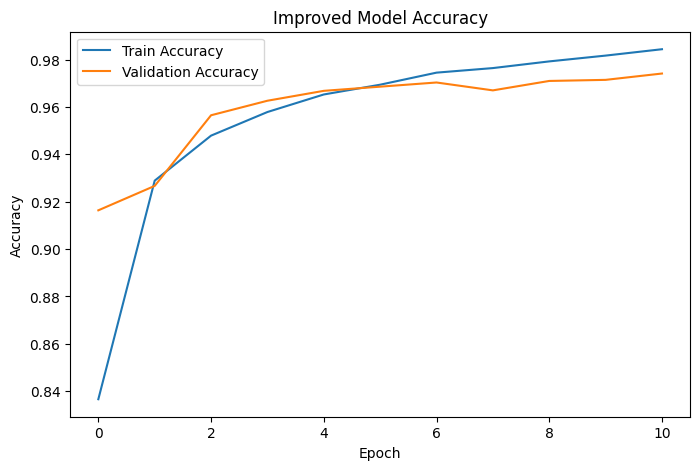

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Improved Model Accuracy')
plt.legend()
plt.show()

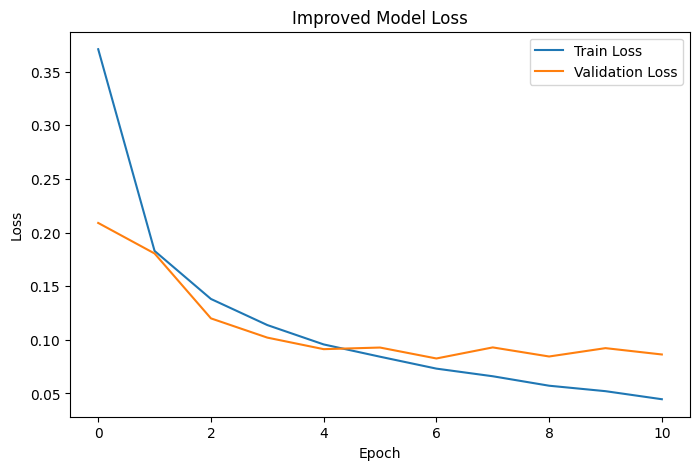

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Improved Model Loss')
plt.legend()
plt.show()

In [17]:
model.save("../models/gru_improved_model.keras")
print("Improved model saved successfully.")

Improved model saved successfully.


In [18]:
import pickle

with open("../models/tokenizer_improved.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Improved tokenizer saved successfully.")

Improved tokenizer saved successfully.


In [21]:
from tensorflow.keras.models import load_model
import pickle

model = load_model("../models/gru_improved_model.keras")

with open("../models/tokenizer_improved.pkl", "rb") as f:
    tokenizer = pickle.load(f)

print("Model and tokenizer loaded.")

Model and tokenizer loaded.


In [24]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 250  # use the same value used in training

def predict_url(url, threshold=0.5):
    original_url = url

    if not url.startswith("http://") and not url.startswith("https://"):
        url = "http://" + url

    seq = tokenizer.texts_to_sequences([url])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    prob = float(model.predict(padded, verbose=0)[0][0])

    result = "Phishing" if prob > threshold else "Legitimate"

    print(f"Original URL: {original_url}")
    print(f"Processed URL: {url}")
    print(f"Sequence: {seq[0][:50]}")
    print(f"Probability: {prob:.6f}")
    print(f"Threshold: {threshold}")
    print(f"Prediction: {result}")

    return prob, result

In [25]:
predict_url("google.com", threshold=0.5)
predict_url("github.com", threshold=0.5)
predict_url("paypal-login-secure.com", threshold=0.5)
predict_url("secure-update-paypal.com/login", threshold=0.5)

Original URL: google.com
Processed URL: http://google.com
Sequence: [13, 2, 2, 7, 22, 1, 1, 19, 6, 6, 19, 17, 3, 5, 8, 6, 11]
Probability: 0.999128
Threshold: 0.5
Prediction: Phishing
Original URL: github.com
Processed URL: http://github.com
Sequence: [13, 2, 2, 7, 22, 1, 1, 19, 9, 2, 13, 20, 18, 5, 8, 6, 11]
Probability: 0.999219
Threshold: 0.5
Prediction: Phishing
Original URL: paypal-login-secure.com
Processed URL: http://paypal-login-secure.com
Sequence: [13, 2, 2, 7, 22, 1, 1, 7, 4, 34, 7, 4, 17, 31, 17, 6, 19, 9, 12, 31, 10, 3, 8, 20, 14, 3, 5, 8, 6, 11]
Probability: 0.999911
Threshold: 0.5
Prediction: Phishing
Original URL: secure-update-paypal.com/login
Processed URL: http://secure-update-paypal.com/login
Sequence: [13, 2, 2, 7, 22, 1, 1, 10, 3, 8, 20, 14, 3, 31, 20, 7, 16, 4, 2, 3, 31, 7, 4, 34, 7, 4, 17, 5, 8, 6, 11, 1, 17, 6, 19, 9, 12]
Probability: 0.997962
Threshold: 0.5
Prediction: Phishing


(0.9979615211486816, 'Phishing')

In [26]:
df = pd.read_csv("../data/processed/dataset_balanced.csv")

print(df[df['url'].str.contains("google", case=False, na=False)][['url', 'label']].head(10))
print(df[df['url'].str.contains("github", case=False, na=False)][['url', 'label']].head(10))
print(df[df['url'].str.contains("paypal", case=False, na=False)][['url', 'label']].head(10))

                                                   url  label
12   http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
17   http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
21   http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
32      http://sites.google.com/site/aaabailbondsinc2/      0
39   http://www.google.nl/url?sa=t&amp;rct=j&amp;q=...      1
58   http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
123  http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
199  http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
296  http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
305  http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
                                                  url  label
5898         http://github.com/buymeasoda/soda-theme/      0
12119  http://schacon.github.com/git/user-manual.html      0
12430             http://visionmedia.github.com/keys/      0
16861           http://idmillington.github.com/rowan/      0
17643        

In [27]:
print("Label 0 samples:")
print(df[df['label'] == 0][['url', 'label']].sample(10, random_state=42))

print("\nLabel 1 samples:")
print(df[df['label'] == 1][['url', 'label']].sample(10, random_state=42))

Label 0 samples:
                                                     url  label
88546  http://www.magma.ca/~davises/Software/Dimensio...      0
20423  http://www.stevenwood.org/stories/2003/06/08/v...      0
75153             http://www.mfsoft.com/equationgrapher/      0
53510             http://www.versiontracker.com/windows/      0
3739        http://www.angelfire.com/ca7/myfun/open.html      0
17504                  http://www.cs.usyd.edu.au/~peter/      0
1956           http://juancarloslondono.tripod.com/Juan/      0
31060                  http://members.tripod.com/AnilBh/      0
75151                  http://tools.ietf.org/html/rfc479      0
66784             http://www.4t-niagara.com/sweeper.html      0

Label 1 samples:
                                                     url  label
88277                 http://9dotlabs.com/brtt/index.php      1
20545  http://klovaks.net/PLO5XIde/webscr_prim.php?a2...      1
74971  http://www.paypal.ca.0838.secure8k.mx/images/c...      1
53511

In [28]:
print(df[df['url'].str.contains("google|github|paypal", case=False, na=False)][['url', 'label']].head(20))

                                                   url  label
12   http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
16   http://center-paypal-resolution-com.cgi-bin.di...      1
17   http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
21   http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
32      http://sites.google.com/site/aaabailbondsinc2/      0
37    http://paypal.com.cmd-cgi.login.metrorumbas.com/      1
39   http://www.google.nl/url?sa=t&amp;rct=j&amp;q=...      1
54   http://www.hormonewellstore.com/ww.paypal.com/...      1
58   http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
97   http://protecintl.com/~calbum/zp-core/paypal.c...      1
123  http://'9d345009-a-62cb3a1a-s-sites.googlegrou...      1
134                   http://www.paypal-protection.tk/      1
148  http://www.marysolfotoevideo.com.br/paypal.com...      1
153  http://paypal.com.cgi-bin.webscr.cmd-login-sub...      1
165  http://lulamako.com/paypal.de/webscr.php?cmd=_...      1
177  htt

In [29]:
sample_rows = df.sample(10, random_state=42)[['url', 'label']]

for _, row in sample_rows.iterrows():
    prob, pred = predict_url(row['url'], threshold=0.5)
    print("Actual label:", row['label'])
    print("-" * 60)

Original URL: http://en.wikipedia.org/wiki/News_server
Processed URL: http://en.wikipedia.org/wiki/News_server
Sequence: [13, 2, 2, 7, 22, 1, 1, 3, 12, 5, 15, 9, 35, 9, 7, 3, 16, 9, 4, 5, 6, 14, 19, 1, 15, 9, 35, 9, 1, 51, 3, 15, 10, 39, 10, 3, 14, 38, 3, 14]
Probability: 0.001970
Threshold: 0.5
Prediction: Legitimate
Actual label: 0
------------------------------------------------------------
Original URL: http://www.angelfire.com/az2/azaroth/
Processed URL: http://www.angelfire.com/az2/azaroth/
Sequence: [13, 2, 2, 7, 22, 1, 1, 15, 15, 15, 5, 4, 12, 19, 3, 17, 21, 9, 14, 3, 5, 8, 6, 11, 1, 4, 42, 26, 1, 4, 42, 4, 14, 6, 2, 13, 1]
Probability: 0.001501
Threshold: 0.5
Prediction: Legitimate
Actual label: 0
------------------------------------------------------------
Original URL: http://www.creativyst.com/Doc/Std/JSMsg/JSMsg.htm
Processed URL: http://www.creativyst.com/Doc/Std/JSMsg/JSMsg.htm
Sequence: [13, 2, 2, 7, 22, 1, 1, 15, 15, 15, 5, 8, 14, 3, 4, 2, 9, 38, 34, 10, 2, 5, 8, 6, 11

In [30]:
real_benign_urls = [
    "google.com",
    "github.com",
    "amazon.com",
    "microsoft.com",
    "bbc.com",
    "wikipedia.org",
    "openai.com",
    "linkedin.com"
]

In [31]:
for url in real_benign_urls:
    predict_url(url, threshold=0.5)
    print("-" * 50)

Original URL: google.com
Processed URL: http://google.com
Sequence: [13, 2, 2, 7, 22, 1, 1, 19, 6, 6, 19, 17, 3, 5, 8, 6, 11]
Probability: 0.999128
Threshold: 0.5
Prediction: Phishing
--------------------------------------------------
Original URL: github.com
Processed URL: http://github.com
Sequence: [13, 2, 2, 7, 22, 1, 1, 19, 9, 2, 13, 20, 18, 5, 8, 6, 11]
Probability: 0.999219
Threshold: 0.5
Prediction: Phishing
--------------------------------------------------
Original URL: amazon.com
Processed URL: http://amazon.com
Sequence: [13, 2, 2, 7, 22, 1, 1, 4, 11, 4, 42, 6, 12, 5, 8, 6, 11]
Probability: 0.999331
Threshold: 0.5
Prediction: Phishing
--------------------------------------------------
Original URL: microsoft.com
Processed URL: http://microsoft.com
Sequence: [13, 2, 2, 7, 22, 1, 1, 11, 9, 8, 14, 6, 10, 6, 21, 2, 5, 8, 6, 11]
Probability: 0.999137
Threshold: 0.5
Prediction: Phishing
--------------------------------------------------
Original URL: bbc.com
Processed URL: http:/